## Babynames.ipynb
# Author Cathal Redmond 7 April 2026
# Goal: Generate a line chart that shows the percentage share of the most popular boys names in Ireland from the years 1964 to 2025, using data from the CSO website. 


In [15]:
##Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##define the file location
URL = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/VSA50/CSV/1.0/"
##read the data into a dataframe
df = pd.read_csv(URL)

##drop the first three columns which are not needed for analysis
df = df.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'UNIT'])

# convert nan values in column 'value' to 0 and 
df = df.fillna(0)
print(df.head())

   Year  C02512V04117 Boys Names  VALUE
0  1964          2677        A J    0.0
1  1964          1232       A.J.    0.0
2  1964          2755      Aahan    0.0
3  1964          2240      Aahil    0.0
4  1964          1001      Aaran    0.0


In [20]:
##covert the data type to integer for the 'VALUE' column
df['VALUE'] = df['VALUE'].astype(int)

## create a new column with the sum or total of the 'VALUE' column for each unique value in the 'Year' column
df['Total'] = df.groupby('Year')['VALUE'].transform('sum')

## create a new column with the percentage of each value in the 'VALUE' column compared to the total for that year
df['Percentage'] = df['VALUE'] / df['Total'] * 100

## create a new colummn with the ranking of each value in the 'VALUE' column for each unique value in the 'Year' column
df['Rank'] = df.groupby('Year')['VALUE'].rank(ascending=False)  

##display the first few rows of the dataframe
print(df.head())



   Year  C02512V04117 Boys Names  VALUE  Total  Percentage    Rank
0  1964          2677        A J      0  66838         0.0  3112.5
1  1964          1232       A.J.      0  66838         0.0  3112.5
2  1964          2755      Aahan      0  66838         0.0  3112.5
3  1964          2240      Aahil      0  66838         0.0  3112.5
4  1964          1001      Aaran      0  66838         0.0  3112.5


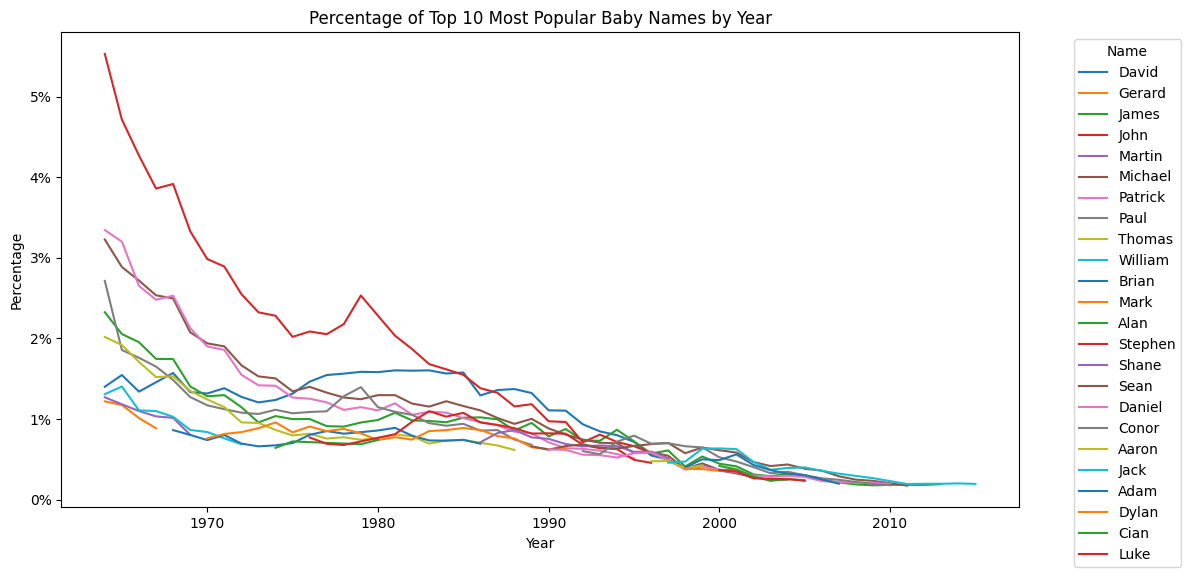

In [48]:
# Create a line chart showing the percentage of the top 10 most popular baby names for each year. Show the names in the legend and label the axes and title of the chart. use seaborn for the line chart. use a different color for each name in the line chart. show the legend outside the plot area on the right side of the chart. display the names sorted in alphabetical order in the legend. only show the top ranked name as coloured lines and the rest as grey lines for each year. use tight_layout to adjust the layout of the chart and make sure the legend does not overlap with the plot area. display the y axis as an exponential scale.         

# Filter the dataframe to only include the top 10 most popular baby names for each year
top_10 = df[df['Rank'] <= 10]
    
# Create a line chart using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=top_10, x='Year', y='Percentage', hue='Boys Names', palette='tab10', legend='full')

# Set the title and labels
plt.title('Percentage of Top 10 Most Popular Baby Names by Year')
plt.xlabel('Year')
plt.ylabel('Percentage')

#show the numbers 0-5 on the y axis in percentage format
plt.yticks(np.arange(0, 6, 1), ['0%', '1%', '2%', '3%', '4%', '5%'])        

# Move the legend outside the plot area on the right side
plt.legend(title='Name', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Set the y-axis to exponential scale
#plt.yscale('log')

# Show the plot
plt.show()  

Year
1964    0.964705
1965    0.961996
1966    0.959186
1967    0.956816
1968    0.958596
          ...   
2021    0.870226
2022    0.867266
2023    0.866786
2024    0.863628
2025    0.857463
Name: VALUE, Length: 62, dtype: float64


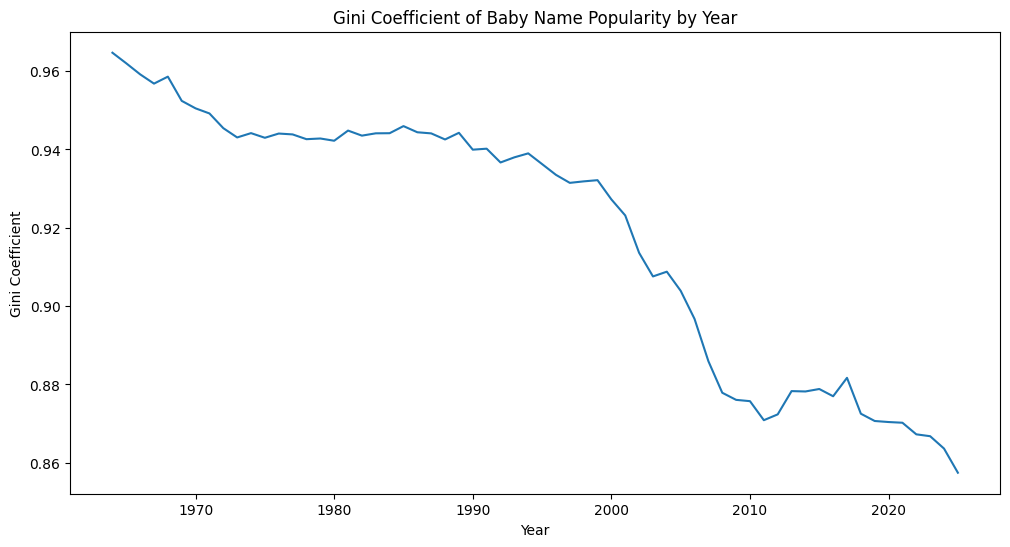

In [54]:
# calculate the ginini coefficient for the 'VALUE' column for each year
def gini_coefficient(x):
    # Sort the values in ascending order
    sorted_x = np.sort(x)
    n = len(x)
    cumulative_x = np.cumsum(sorted_x)
    gini = (n + 1 - 2 * np.sum(cumulative_x) / cumulative_x[-1]) / n
    return gini 
gini_by_year = df.groupby('Year')['VALUE'].apply(gini_coefficient)
print(gini_by_year)

# plot the gini coefficient for each year as a line chart using seaborn    
plt.figure(figsize=(12, 6))
sns.lineplot(x=gini_by_year.index, y=gini_by_year.values)
plt.title('Gini Coefficient of Baby Name Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Gini Coefficient')
plt.show()  